# Log Severity Classifier — Fine-tuning ModernBERT-base

This notebook fine-tunes `answerdotai/ModernBERT-base` (150M params, 8192 context) for **chunk-level log severity classification**.

**Task:** Given a chunk of log lines (~2 min window), classify the chunk into one of 4 severity levels:

| Label ID | Class | Meaning |
|----------|-------|------|
| 0 | `FATAL_OR_CRITICAL` | System crash, unrecoverable errors, service down |
| 1 | `ERROR` | Recoverable errors — exceptions, failed requests, 5xx |
| 2 | `WARNING` | Degradation signals — high latency, retries, deprecations |
| 3 | `NORMAL` | Only INFO/DEBUG/TRACE lines, no anomalies |

**Architecture:** ModernBERT encoder → Linear classification head (768 → 4)

**Datasets:** BGL (BlueGene/L supercomputer logs from Loghub) as primary data source. Synthetic data from web apps, nginx, Android, OS logs will be added later.

---

## Section 1: Setup & Dependencies

In [ ]:
# ============================================================
# Cell 1: Install dependencies
# ============================================================
!pip install -q transformers>=4.48.0 datasets accelerate scikit-learn seaborn
!pip install -q torch torchvision  # usually pre-installed on Colab

# Flash Attention 2 — only works on Ampere+ GPUs (A100, L4, etc.)
# T4 will silently fall back to standard attention, which is fine.
# Uncomment if you're on A100/L4:
# !pip install -q flash-attn --no-build-isolation

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [ ]:
# ============================================================
# Cell 2: Mount Google Drive & create directory structure
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# Base project directory on Google Drive
PROJECT_DIR = '/content/drive/MyDrive/log_severity_classifier'
RAW_DATA_DIR = os.path.join(PROJECT_DIR, 'raw_data')
PROCESSED_DATA_DIR = os.path.join(PROJECT_DIR, 'processed_data')
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')

for d in [PROJECT_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f"✓ {d}")

Mounted at /content/drive
✓ /content/drive/MyDrive/log_severity_classifier
✓ /content/drive/MyDrive/log_severity_classifier/raw_data
✓ /content/drive/MyDrive/log_severity_classifier/processed_data
✓ /content/drive/MyDrive/log_severity_classifier/models


## Section 2: Data Download (One-Time Prerequisite)

Run this section **once** to download the BGL dataset from Loghub/Zenodo and save it to Google Drive. After that, you can skip directly to Section 3.

**BGL Dataset:** ~4.7M log lines from the BlueGene/L supercomputer at Lawrence Livermore National Labs. Each line is labeled with alert category tags and severity levels (FATAL, ERROR, WARNING, INFO), making it ideal for our severity classification task.

In [ ]:
# ============================================================
# Cell 3: Download BGL dataset from Loghub (ONE-TIME CELL)
# ============================================================
import os
import urllib.request
import zipfile
import shutil

BGL_DEST = os.path.join(RAW_DATA_DIR, 'BGL.log')

if os.path.exists(BGL_DEST) and os.path.getsize(BGL_DEST) > 1_000_000:
    print(f"BGL.log already exists at {BGL_DEST}")
    print(f"Size: {os.path.getsize(BGL_DEST) / 1e6:.1f} MB")
    print("Skipping download. Delete the file if you want to re-download.")
else:
    # Correct URL: it's a .zip, not .tar.gz
    ZENODO_URL = 'https://zenodo.org/records/8196385/files/BGL.zip?download=1'
    TMP_ZIP = '/content/BGL.zip'
    TMP_EXTRACT = '/content/bgl_extract'

    print("Downloading BGL dataset from Zenodo (~57.5 MB)...")

    try:
        urllib.request.urlretrieve(ZENODO_URL, TMP_ZIP)
        print(f"Downloaded: {os.path.getsize(TMP_ZIP) / 1e6:.1f} MB")

        print("Extracting...")
        os.makedirs(TMP_EXTRACT, exist_ok=True)
        with zipfile.ZipFile(TMP_ZIP, 'r') as z:
            z.extractall(TMP_EXTRACT)

        # Find the BGL.log file
        extracted_log = None
        for root, dirs, files in os.walk(TMP_EXTRACT):
            for f in files:
                if f.endswith('.log') or f == 'BGL.log':
                    extracted_log = os.path.join(root, f)
                    break
            # Also check for files without extension that are large
            if not extracted_log:
                for f in files:
                    fp = os.path.join(root, f)
                    if os.path.getsize(fp) > 1_000_000:
                        extracted_log = fp
                        break

        if extracted_log:
            shutil.copy2(extracted_log, BGL_DEST)
            print(f"✓ Saved to {BGL_DEST}")
            print(f"  Size: {os.path.getsize(BGL_DEST) / 1e6:.1f} MB")
        else:
            print("Could not find BGL.log in extracted files.")
            print("Extracted contents:")
            for root, dirs, files in os.walk(TMP_EXTRACT):
                for f in files:
                    fp = os.path.join(root, f)
                    print(f"  {fp} ({os.path.getsize(fp)/1e6:.1f} MB)")

        # Cleanup
        if os.path.exists(TMP_ZIP):
            os.remove(TMP_ZIP)
        if os.path.exists(TMP_EXTRACT):
            shutil.rmtree(TMP_EXTRACT)

    except Exception as e:
        print(f"\n⚠ Download failed: {e}")
        print("Manual alternative: go to https://zenodo.org/records/8196385")
        print("Download BGL.zip, extract it, and upload BGL.log to:")
        print(f"  {RAW_DATA_DIR}")

Downloaded: 57.5 MB
Extracting...
✓ Saved to /content/drive/MyDrive/log_severity_classifier/raw_data/BGL.log
  Size: 743.2 MB


In [ ]:
# ============================================================
# Cell 4: Quick peek at the raw data
# ============================================================
BGL_DEST = os.path.join(RAW_DATA_DIR, 'BGL.log')

with open(BGL_DEST, 'r', errors='replace') as f:
    sample_lines = [f.readline() for _ in range(10)]

print("First 10 lines of BGL.log:")
print("=" * 100)
for i, line in enumerate(sample_lines):
    print(f"[{i}] {line.rstrip()[:120]}")

# Count total lines
with open(BGL_DEST, 'r', errors='replace') as f:
    total_lines = sum(1 for _ in f)
print(f"\nTotal lines: {total_lines:,}")

First 10 lines of BGL.log:
[0] - 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.363779 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction c
[1] - 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.527847 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction c
[2] - 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.675872 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction c
[3] - 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.823719 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction c
[4] - 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.982731 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction c
[5] - 1117838571 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.51.131467 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction c
[6] - 1117838571 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.51.293532 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction c
[7] - 1117838571 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.51.428563 R02-M1-N0-C:J12-U11 RAS

## Section 3: Load Data from Google Drive & Preprocess

**Parsing strategy for BGL:**
- BGL format: `<Label> <Timestamp> <Date> <Node> <DateTime> <NodeRepeat> <Type> <Component> <Level> <Content...>`
- The `Level` field (index 8) contains: FATAL, FAILURE, SEVERE, ERROR, WARNING, INFO
- The `Label` field (index 0): `-` for non-alert, or an alert category tag
- We use both fields to determine per-line severity

**Chunking strategy:**
- Group consecutive lines into chunks (simulating 2-min windows)
- Label each chunk by its **highest severity** line (worst-case escalation)
- This matches the real-world use case: "does this 2-min window contain any errors?"

In [ ]:
# ============================================================
# Cell 5: Configuration
# ============================================================

# --- Data Processing Config ---
CHUNK_SIZE = 30          # Number of log lines per chunk
CHUNK_STRIDE = 15        # Sliding window stride (50% overlap)
MAX_LINES = None         # Set to e.g. 1_000_000 to limit data size, None for all

# --- Class Labels ---
LABEL_MAP = {
    'FATAL_OR_CRITICAL': 0,
    'ERROR': 1,
    'WARNING': 2,
    'NORMAL': 3
}
ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}

# --- Training Config ---
MODEL_ID = 'answerdotai/ModernBERT-base'
MAX_SEQ_LENGTH = 2048    # Max tokens per chunk (ModernBERT supports up to 8192)
BATCH_SIZE = 8           # Per-device batch size (adjust for VRAM)
LEARNING_RATE = 2e-5
NUM_EPOCHS = 5
WARMUP_RATIO = 0.1

print("Config loaded.")
print(f"Classes: {LABEL_MAP}")
print(f"Chunk size: {CHUNK_SIZE} lines, stride: {CHUNK_STRIDE}")

Config loaded.
Classes: {'FATAL_OR_CRITICAL': 0, 'ERROR': 1, 'WARNING': 2, 'NORMAL': 3}
Chunk size: 30 lines, stride: 15


In [ ]:
# ============================================================
# Cell 6: Parse BGL log lines & assign per-line severity
# ============================================================
import re
from collections import Counter

def classify_bgl_line(line):
    """
    Classify a single BGL log line into severity.
    Returns (severity_str, cleaned_text_without_label)

    BGL format:
    <Label> <Timestamp> <Date> <Node> <DateTime> <NodeRepeat> <Type> <Component> <Level> <Content...>
    """
    line = line.strip()
    if not line:
        return 'NORMAL', ''

    parts = line.split(None, 9)  # Split into max 10 parts
    if len(parts) < 9:
        return 'NORMAL', line

    alert_tag = parts[0]    # "-" or alert category (KERNDTLB, etc.)
    level = parts[8].upper() if len(parts) > 8 else ''

    # Build cleaned text: remove the label column (index 0) so the model
    # can't cheat by just reading "-" vs non-"-"
    cleaned = ' '.join(parts[1:])

    # Determine severity
    if level in ('FATAL', 'FAILURE', 'SEVERE'):
        return 'FATAL_OR_CRITICAL', cleaned
    elif level == 'ERROR':
        return 'ERROR', cleaned
    elif level in ('WARNING', 'WARN'):
        return 'WARNING', cleaned
    elif alert_tag != '-':
        # Has an alert tag but level is INFO → still an anomaly, treat as ERROR
        return 'ERROR', cleaned
    else:
        return 'NORMAL', cleaned


# Parse all lines
BGL_DEST = os.path.join(RAW_DATA_DIR, 'BGL.log')
parsed_lines = []  # List of (severity, cleaned_text)

print("Parsing BGL log lines...")
with open(BGL_DEST, 'r', errors='replace') as f:
    for i, line in enumerate(f):
        if MAX_LINES and i >= MAX_LINES:
            break
        severity, text = classify_bgl_line(line)
        if text:  # Skip empty lines
            parsed_lines.append((severity, text))

# Stats
severity_counts = Counter(sev for sev, _ in parsed_lines)
print(f"\nParsed {len(parsed_lines):,} lines")
print("\nPer-line severity distribution:")
for sev, count in severity_counts.most_common():
    pct = count / len(parsed_lines) * 100
    print(f"  {sev:20s}: {count:>10,} ({pct:.2f}%)")

Parsing BGL log lines...

Parsed 4,747,963 lines

Per-line severity distribution:
  NORMAL              :  3,736,129 (78.69%)
  FATAL_OR_CRITICAL   :    876,122 (18.45%)
  ERROR               :    112,355 (2.37%)


In [ ]:
# ============================================================
# Cell 7: Create chunks with sliding window & assign labels
# ============================================================
import json
import random

# Severity priority (lower number = higher severity)
SEVERITY_PRIORITY = {
    'FATAL_OR_CRITICAL': 0,
    'ERROR': 1,
    'WARNING': 2,
    'NORMAL': 3
}

def create_chunks(parsed_lines, chunk_size, stride):
    """
    Sliding window chunking.
    Each chunk is labeled by its highest-severity line.
    Returns list of {text, label, label_name, line_severities}
    """
    chunks = []
    for start in range(0, len(parsed_lines) - chunk_size + 1, stride):
        window = parsed_lines[start:start + chunk_size]

        # Chunk text: join all cleaned log lines
        text = '\n'.join(t for _, t in window)

        # Chunk label: highest severity in window
        severities = [s for s, _ in window]
        worst = min(severities, key=lambda s: SEVERITY_PRIORITY[s])
        label_id = LABEL_MAP[worst]

        chunks.append({
            'text': text,
            'label': label_id,
            'label_name': worst
        })

    return chunks


print(f"Creating chunks (size={CHUNK_SIZE}, stride={CHUNK_STRIDE})...")
all_chunks = create_chunks(parsed_lines, CHUNK_SIZE, CHUNK_STRIDE)

# Stats
chunk_label_counts = Counter(c['label_name'] for c in all_chunks)
print(f"\nTotal chunks: {len(all_chunks):,}")
print("\nChunk-level label distribution:")
for label_name, count in chunk_label_counts.most_common():
    pct = count / len(all_chunks) * 100
    print(f"  {label_name:20s}: {count:>10,} ({pct:.2f}%)")

# Show a sample
print("\n--- Sample chunk (first ERROR chunk) ---")
for c in all_chunks:
    if c['label_name'] == 'ERROR':
        print(f"Label: {c['label_name']} (id={c['label']})")
        print(f"Text (first 300 chars):\n{c['text'][:300]}")
        break

Creating chunks (size=30, stride=15)...

Total chunks: 316,529

Chunk-level label distribution:
  NORMAL              :    243,944 (77.07%)
  FATAL_OR_CRITICAL   :     65,548 (20.71%)
  ERROR               :      6,657 (2.10%)

--- Sample chunk (first ERROR chunk) ---
Label: ERROR (id=1)
Text (first 300 chars):
1120241338 2005.07.01 R11-M0-N1 2005-07-01-11.08.58.468939 R11-M0-N1 NULL DISCOVERY ERROR Node card status: no ALERTs are active. Clock Mode is Low. Clock Select is Midplane. Phy JTAG Reset is asserted. ASIC JTAG Reset is asserted. Temperature Mask is not active. No temperature error. Temperature Li


In [ ]:
# ============================================================
# Cell 8: Balance classes & create train/val/test splits
# ============================================================
# Log data is heavily imbalanced (mostly NORMAL). We'll downsample
# the majority class and slightly oversample minority classes.

from collections import defaultdict

# Group chunks by label
by_label = defaultdict(list)
for c in all_chunks:
    by_label[c['label']].append(c)

print("Raw counts per class:")
for lid in sorted(by_label.keys()):
    print(f"  {ID_TO_LABEL[lid]:20s}: {len(by_label[lid]):,}")

# Determine target size per class
# Strategy: cap majority at N, keep minority as-is (with optional oversampling)
counts = {lid: len(chunks) for lid, chunks in by_label.items()}
min_count = min(counts.values())
max_target = min(min_count * 5, 20000)  # Cap at 5x minority or 20K

balanced = []
for lid in sorted(by_label.keys()):
    chunks = by_label[lid]
    random.seed(42)
    if len(chunks) > max_target:
        # Downsample
        sampled = random.sample(chunks, max_target)
    elif len(chunks) < max_target:
        # Oversample with repetition (if needed)
        sampled = chunks.copy()
        while len(sampled) < min(max_target, len(chunks) * 3):
            sampled.extend(random.sample(chunks, min(len(chunks), max_target - len(sampled))))
    else:
        sampled = chunks
    balanced.extend(sampled)
    print(f"  {ID_TO_LABEL[lid]:20s}: {len(chunks):>8,} → {len(sampled):>8,}")

random.shuffle(balanced)
print(f"\nTotal balanced samples: {len(balanced):,}")

# Split: 80% train, 10% val, 10% test
n = len(balanced)
train_end = int(0.8 * n)
val_end = int(0.9 * n)

train_data = balanced[:train_end]
val_data = balanced[train_end:val_end]
test_data = balanced[val_end:]

print(f"\nSplits: train={len(train_data):,}, val={len(val_data):,}, test={len(test_data):,}")

Raw counts per class:
  FATAL_OR_CRITICAL   : 65,548
  ERROR               : 6,657
  NORMAL              : 243,944
  FATAL_OR_CRITICAL   :   65,548 →    1,900
  ERROR               :    6,657 →    1,900
  NORMAL              :  243,944 →    1,900

Total balanced samples: 6,840

Splits: train=5,472, val=684, test=684


In [ ]:
# ============================================================
# Cell 9: Save processed data to Google Drive (JSONL format)
# ============================================================
# This standardized format makes it easy to combine with
# synthetic data later. Schema: {"text": str, "label": int}

import json

def save_jsonl(data, filepath):
    """Save list of dicts as JSONL (one JSON object per line)."""
    with open(filepath, 'w') as f:
        for item in data:
            # Only save text and label (not label_name) for clean schema
            f.write(json.dumps({'text': item['text'], 'label': item['label']}) + '\n')
    print(f"✓ Saved {len(data):,} samples to {filepath}")

# Save splits
# Tag these as "bgl" source so we can distinguish from synthetic data later
save_jsonl(train_data, os.path.join(PROCESSED_DATA_DIR, 'bgl_train.jsonl'))
save_jsonl(val_data, os.path.join(PROCESSED_DATA_DIR, 'bgl_val.jsonl'))
save_jsonl(test_data, os.path.join(PROCESSED_DATA_DIR, 'bgl_test.jsonl'))

# Also save the full label map for reference
meta = {
    'label_map': LABEL_MAP,
    'id_to_label': ID_TO_LABEL,
    'chunk_size': CHUNK_SIZE,
    'chunk_stride': CHUNK_STRIDE,
    'source': 'bgl_loghub',
    'model_id': MODEL_ID
}
with open(os.path.join(PROCESSED_DATA_DIR, 'metadata.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print(f"✓ Saved metadata to {PROCESSED_DATA_DIR}/metadata.json")

✓ Saved 5,472 samples to /content/drive/MyDrive/log_severity_classifier/processed_data/bgl_train.jsonl
✓ Saved 684 samples to /content/drive/MyDrive/log_severity_classifier/processed_data/bgl_val.jsonl
✓ Saved 684 samples to /content/drive/MyDrive/log_severity_classifier/processed_data/bgl_test.jsonl
✓ Saved metadata to /content/drive/MyDrive/log_severity_classifier/processed_data/metadata.json


## Section 4: Load Processed Data & Prepare for Training

From here on, this section loads data from Google Drive. When you add synthetic data later, you'll modify the loading cell to combine multiple JSONL files.

In [ ]:
# ============================================================
# Cell 10: Load processed BGL data & Synthetic Data
# ============================================================
import json
import os
import zipfile
from collections import Counter

PROCESSED_DATA_DIR = '/content/drive/MyDrive/log_severity_classifier/processed_data'
SYNTHETIC_ZIP_PATH = '/content/drive/MyDrive/synthetic_raw.zip'
SYNTHETIC_EXTRACT_DIR = '/content/synthetic_raw'

def load_jsonl(filepath):
    """Load JSONL file into list of dicts."""
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

def load_and_combine(file_list):
    """Load and combine multiple JSONL files."""
    combined = []
    for fp in file_list:
        if os.path.exists(fp):
            items = load_jsonl(fp)
            combined.extend(items)
            print(f"  Loaded {len(items):,} samples from {os.path.basename(fp)}")
        else:
            print(f"  ⚠ Not found: {fp}")
    return combined

# ---- Part 1: Load BGL Data ----
train_files = [os.path.join(PROCESSED_DATA_DIR, 'bgl_train.jsonl')]
val_files = [os.path.join(PROCESSED_DATA_DIR, 'bgl_val.jsonl')]
test_files = [os.path.join(PROCESSED_DATA_DIR, 'bgl_test.jsonl')]

print("Loading BGL training data:")
train_data = load_and_combine(train_files)
print(f"\nLoading BGL validation data:")
val_data = load_and_combine(val_files)
print(f"\nLoading BGL test data:")
test_data = load_and_combine(test_files)

# ---- Part 2: Extract & Load Synthetic Data ----
if os.path.exists(SYNTHETIC_ZIP_PATH):
    print(f"\nExtracting Synthetic Data from {SYNTHETIC_ZIP_PATH}...")
    os.makedirs(SYNTHETIC_EXTRACT_DIR, exist_ok=True)

    with zipfile.ZipFile(SYNTHETIC_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(SYNTHETIC_EXTRACT_DIR)

    synth_train, synth_val, synth_test = [], [], []

    # Process extracted JSONL files safely
    for root, _, files in os.walk(SYNTHETIC_EXTRACT_DIR):
        for f in files:
            if f.endswith('.jsonl'):
                filepath = os.path.join(root, f)
                items = load_jsonl(filepath)

                # Split rigorously by the 'set' field generated earlier
                for item in items:
                    # Uniform schema requirement: {"text": str, "label": int}
                    clean_item = {'text': item['text'], 'label': item['label']}
                    set_num = item.get('set', 1)

                    if set_num in [1, 2, 3]:       # 60% Training
                        synth_train.append(clean_item)
                    elif set_num == 4:             # 20% Validation
                        synth_val.append(clean_item)
                    elif set_num == 5:             # 20% Testing
                        synth_test.append(clean_item)

    print(f"✓ Added Synthetic Data: Train={len(synth_train)}, Val={len(synth_val)}, Test={len(synth_test)}")

    # Mix synthetic data directly into the splits
    train_data.extend(synth_train)
    val_data.extend(synth_val)
    test_data.extend(synth_test)
else:
    print(f"\n⚠ Synthetic data zip not found at {SYNTHETIC_ZIP_PATH}")

print(f"\n{'='*50}")
print(f"Final Total Combined: train={len(train_data):,}, val={len(val_data):,}, test={len(test_data):,}")

# Verify final label distribution across the merged datasets
LABEL_MAP = {'FATAL_OR_CRITICAL': 0, 'ERROR': 1, 'WARNING': 2, 'NORMAL': 3}
ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}

print("\nFinal Train Label Distribution:")
for label_id, count in sorted(Counter(d['label'] for d in train_data).items()):
    print(f"  {ID_TO_LABEL[label_id]:20s}: {count:,}")

Loading BGL training data:
  Loaded 5,472 samples from bgl_train.jsonl

Loading BGL validation data:
  Loaded 684 samples from bgl_val.jsonl

Loading BGL test data:
  Loaded 684 samples from bgl_test.jsonl

Extracting Synthetic Data from /content/drive/MyDrive/synthetic_raw.zip...
✓ Added Synthetic Data: Train=1800, Val=600, Test=600

Final Total Combined: train=7,272, val=1,284, test=1,284

Final Train Label Distribution:
  FATAL_OR_CRITICAL   : 1,992
  ERROR               : 1,950
  NORMAL              : 1,977


In [ ]:
# ============================================================
# Cell 11: Convert to HuggingFace Dataset & tokenize
# ============================================================
from datasets import Dataset
from transformers import AutoTokenizer

MODEL_ID = 'answerdotai/ModernBERT-base'
MAX_SEQ_LENGTH = 2048

# Convert to HF Datasets
train_ds = Dataset.from_list(train_data)
val_ds = Dataset.from_list(val_data)
test_ds = Dataset.from_list(test_data)

print(f"Train: {train_ds}")
print(f"Val:   {val_ds}")
print(f"Test:  {test_ds}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        return_tensors=None  # Return lists, not tensors (for .map())
    )

print("\nTokenizing datasets...")
train_ds = train_ds.map(tokenize_fn, batched=True, batch_size=256,
                        remove_columns=['text'])
val_ds = val_ds.map(tokenize_fn, batched=True, batch_size=256,
                    remove_columns=['text'])
test_ds = test_ds.map(tokenize_fn, batched=True, batch_size=256,
                      remove_columns=['text'])

# Rename label → labels (HF Trainer convention)
train_ds = train_ds.rename_column('label', 'labels')
val_ds = val_ds.rename_column('label', 'labels')
test_ds = test_ds.rename_column('label', 'labels')

# Set format
train_ds.set_format('torch')
val_ds.set_format('torch')
test_ds.set_format('torch')

print(f"\n✓ Tokenization complete")
print(f"  Columns: {train_ds.column_names}")
print(f"  Sample input_ids shape: {len(train_ds[0]['input_ids'])}")

Train: Dataset({
    features: ['text', 'label'],
    num_rows: 7272
})
Val:   Dataset({
    features: ['text', 'label'],
    num_rows: 1284
})
Test:  Dataset({
    features: ['text', 'label'],
    num_rows: 1284
})


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]


Tokenizing datasets...


Map:   0%|          | 0/7272 [00:00<?, ? examples/s]

Map:   0%|          | 0/1284 [00:00<?, ? examples/s]

Map:   0%|          | 0/1284 [00:00<?, ? examples/s]


✓ Tokenization complete
  Columns: ['labels', 'input_ids', 'attention_mask']
  Sample input_ids shape: 2048


## Section 5: Fine-tune ModernBERT

In [ ]:
# ============================================================
# Cell 12: Load ModernBERT with classification head
# ============================================================
from transformers import AutoModelForSequenceClassification
import torch

NUM_LABELS = len(LABEL_MAP)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
    torch_dtype=torch.float32,    # Use float32 on T4 for stability
    # classifier_pooling='cls',   # Default pooling strategy
)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_ID}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Classification head: 768 → {NUM_LABELS} classes")
print(f"Labels: {ID_TO_LABEL}")

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: answerdotai/ModernBERT-base
Total parameters: 149,607,940
Trainable parameters: 149,607,940
Classification head: 768 → 4 classes
Labels: {0: 'FATAL_OR_CRITICAL', 1: 'ERROR', 2: 'WARNING', 3: 'NORMAL'}


In [ ]:
# ============================================================
# Cell 13: Define metrics & training arguments
# ============================================================
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import TrainingArguments, Trainer

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
        'precision_macro': precision_score(labels, preds, average='macro', zero_division=0),
        'recall_macro': recall_score(labels, preds, average='macro', zero_division=0),
    }


BATCH_SIZE = 8
NUM_EPOCHS = 5
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1
MODEL_OUTPUT_DIR = '/content/drive/MyDrive/log_severity_classifier/models'

training_args = TrainingArguments(
    output_dir='/content/checkpoints',
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=0.01,
    lr_scheduler_type='cosine',
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=50,
    fp16=torch.cuda.is_available(),  # Mixed precision on GPU
    dataloader_num_workers=2,
    report_to='none',  # Set to 'wandb' if using W&B
    seed=42,
)

print("Training arguments configured.")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  FP16: {training_args.fp16}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training arguments configured.
  Epochs: 5
  Batch size: 8
  Learning rate: 2e-05
  FP16: True


In [ ]:
# ============================================================
# Cell 14: Train!
# ============================================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("Starting training...")
print(f"Train samples: {len(train_ds):,}")
print(f"Val samples: {len(val_ds):,}")
print(f"Steps per epoch: {len(train_ds) // BATCH_SIZE:,}")
print("=" * 60)

train_result = trainer.train()

# Print training summary
print("\n" + "=" * 60)
print("Training complete!")
print(f"  Total time: {train_result.metrics['train_runtime']:.0f}s")
print(f"  Samples/sec: {train_result.metrics['train_samples_per_second']:.1f}")
print(f"  Final train loss: {train_result.metrics['train_loss']:.4f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Starting training...
Train samples: 7,272
Val samples: 1,284
Steps per epoch: 909


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
1,0.153003,0.262059,0.922897,0.923198,0.923448,0.929346,0.920357
2,0.069330,0.321830,0.911215,0.910407,0.912336,0.919015,0.909324
3,0.129266,0.251716,0.938474,0.938595,0.939279,0.943320,0.937479
4,0.049146,0.266450,0.926012,0.925130,0.926604,0.925736,0.927512
5,0.026443,0.314671,0.921340,0.920944,0.921672,0.922927,0.921884


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
1,0.153003,0.262059,0.922897,0.923198,0.923448,0.929346,0.920357
2,0.069330,0.321830,0.911215,0.910407,0.912336,0.919015,0.909324
3,0.129266,0.251716,0.938474,0.938595,0.939279,0.943320,0.937479
4,0.049146,0.266450,0.926012,0.925130,0.926604,0.925736,0.927512
5,0.026443,0.314671,0.921340,0.920944,0.921672,0.922927,0.921884



Training complete!
  Total time: 1568s
  Samples/sec: 23.2
  Final train loss: 0.1402


## Section 6: Evaluation

In [ ]:
# ============================================================
# Cell 15: Evaluate on test set
# ============================================================
print("Evaluating on test set...")
test_results = trainer.evaluate(test_ds)

print("\nTest Results:")
print(f"  Accuracy:        {test_results['eval_accuracy']:.4f}")
print(f"  F1 (macro):      {test_results['eval_f1_macro']:.4f}")
print(f"  F1 (weighted):   {test_results['eval_f1_weighted']:.4f}")
print(f"  Precision:       {test_results['eval_precision_macro']:.4f}")
print(f"  Recall:          {test_results['eval_recall_macro']:.4f}")

Evaluating on test set...



Test Results:
  Accuracy:        0.9073
  F1 (macro):      0.9069
  F1 (weighted):   0.9075
  Precision:       0.9165
  Recall:          0.9041



Classification Report:
                   precision    recall  f1-score   support

FATAL_OR_CRITICAL     0.9764    0.8529    0.9105       340
            ERROR     0.9220    0.9193    0.9206       347
          WARNING     0.9442    0.8560    0.8980       257
           NORMAL     0.8235    0.9882    0.8984       340

         accuracy                         0.9073      1284
        macro avg     0.9165    0.9041    0.9069      1284
     weighted avg     0.9148    0.9073    0.9075      1284



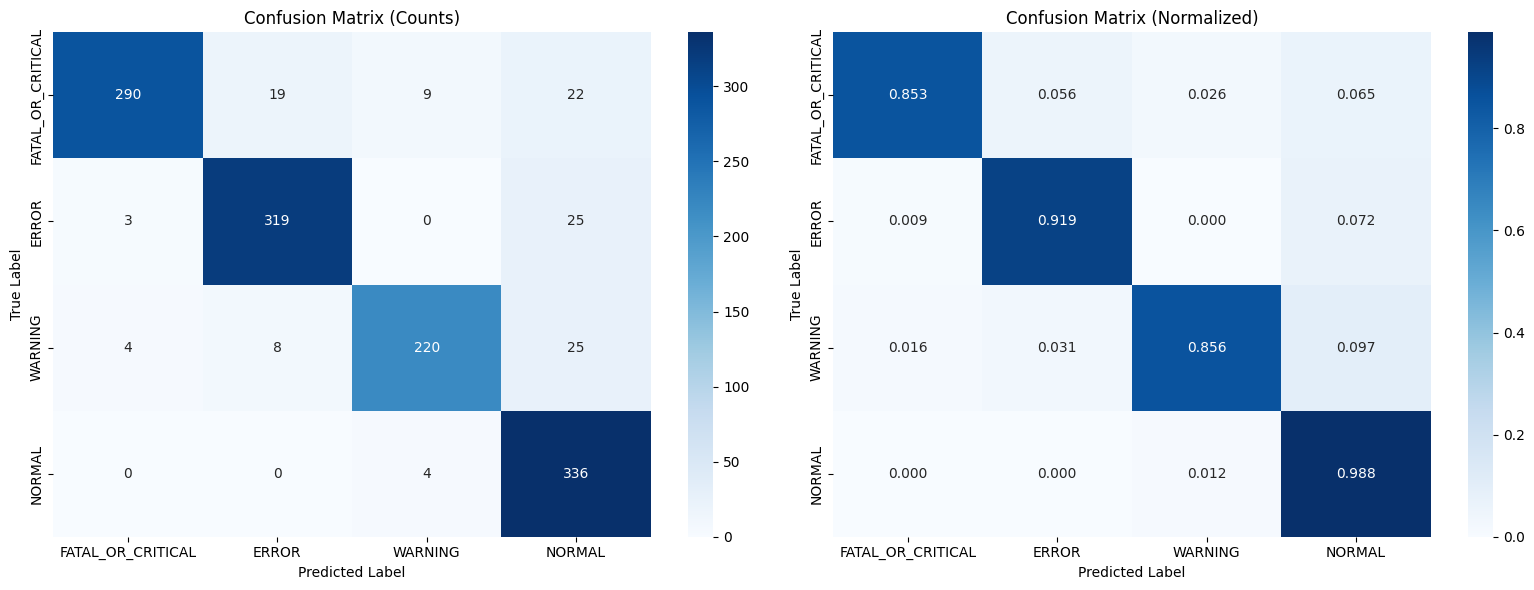


✓ Confusion matrix saved to /content/drive/MyDrive/log_severity_classifier/models/confusion_matrix.png


In [ ]:
# ============================================================
# Cell 16: Confusion matrix & per-class report
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]

# Classification report
print("\nClassification Report:")
print("=" * 70)
print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Confusion matrix saved to {MODEL_OUTPUT_DIR}/confusion_matrix.png")

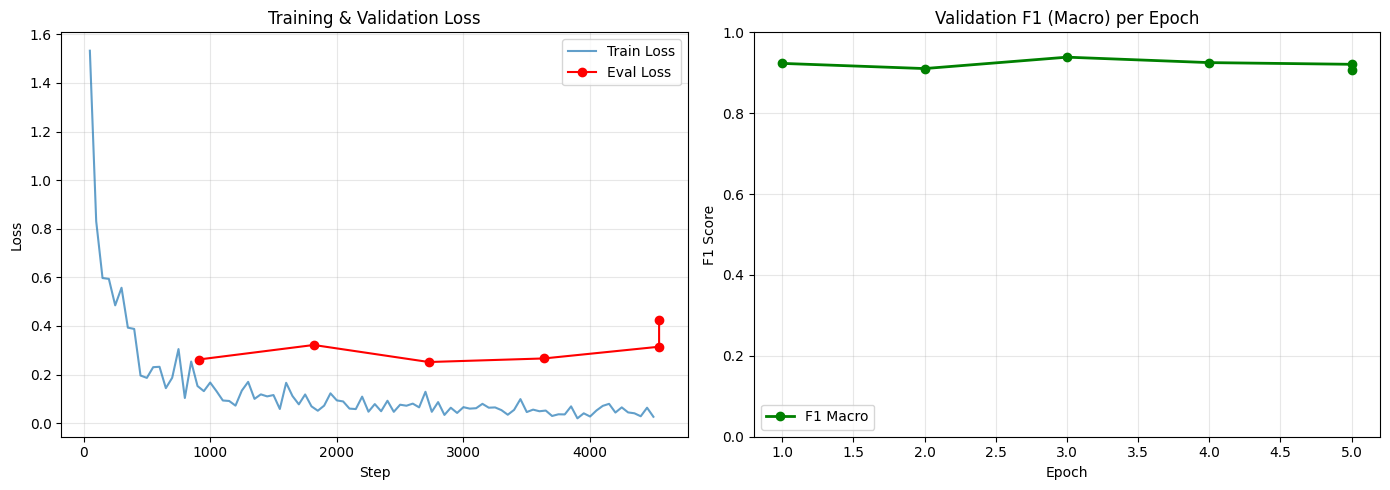

In [ ]:
# ============================================================
# Cell 17: Training loss curve
# ============================================================
# Plot training and eval metrics across epochs

history = trainer.state.log_history

# Extract training loss
train_steps = [h['step'] for h in history if 'loss' in h]
train_losses = [h['loss'] for h in history if 'loss' in h]

# Extract eval metrics
eval_epochs = [h['epoch'] for h in history if 'eval_loss' in h]
eval_losses = [h['eval_loss'] for h in history if 'eval_loss' in h]
eval_f1s = [h['eval_f1_macro'] for h in history if 'eval_f1_macro' in h]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_steps, train_losses, label='Train Loss', alpha=0.7)
if eval_epochs:
    eval_steps_approx = [int(e * len(train_ds) / BATCH_SIZE) for e in eval_epochs]
    axes[0].plot(eval_steps_approx, eval_losses, 'ro-', label='Eval Loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 curve
if eval_epochs:
    axes[1].plot(eval_epochs, eval_f1s, 'go-', label='F1 Macro', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title('Validation F1 (Macro) per Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 7: Save Model & Inference Demo

In [ ]:
# ============================================================
# Cell 18: Save the fine-tuned model to Google Drive
# ============================================================
import json

SAVE_PATH = os.path.join(MODEL_OUTPUT_DIR, 'modernbert-log-severity-v1')

# Save model + tokenizer
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

# Save training metadata alongside the model
training_meta = {
    'model_id': MODEL_ID,
    'label_map': LABEL_MAP,
    'id_to_label': ID_TO_LABEL,
    'max_seq_length': MAX_SEQ_LENGTH,
    'chunk_size': CHUNK_SIZE,
    'chunk_stride': CHUNK_STRIDE,
    'num_epochs': NUM_EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'test_results': {k: float(v) for k, v in test_results.items()},
    'data_sources': ['bgl_loghub'],
}
with open(os.path.join(SAVE_PATH, 'training_metadata.json'), 'w') as f:
    json.dump(training_meta, f, indent=2)

print(f"✓ Model saved to {SAVE_PATH}")
print(f"  Contents:")
for f_name in sorted(os.listdir(SAVE_PATH)):
    f_size = os.path.getsize(os.path.join(SAVE_PATH, f_name))
    print(f"    {f_name:40s} {f_size/1e6:.1f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model saved to /content/drive/MyDrive/log_severity_classifier/models/modernbert-log-severity-v1
  Contents:
    config.json                              0.0 MB
    model.safetensors                        598.4 MB
    tokenizer.json                           3.6 MB
    tokenizer_config.json                    0.0 MB
    training_args.bin                        0.0 MB
    training_metadata.json                   0.0 MB


In [ ]:
# ============================================================
# Cell 19: Inference demo — classify raw log chunks
# ============================================================
from transformers import pipeline
import torch

# Load from saved model (simulates production loading)
SAVE_PATH = os.path.join(MODEL_OUTPUT_DIR, 'modernbert-log-severity-v1')

classifier = pipeline(
    'text-classification',
    model=SAVE_PATH,
    tokenizer=SAVE_PATH,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=MAX_SEQ_LENGTH,
)

# ---- Test with sample log chunks ----

test_chunks = [
    # Chunk 1: Normal operations
    """2024-01-15 10:23:45 INFO  Starting scheduled backup process
2024-01-15 10:23:46 INFO  Connected to database server at 10.0.1.50:5432
2024-01-15 10:23:47 INFO  Backup of schema 'public' started
2024-01-15 10:23:52 INFO  Exported 15,234 rows from users table
2024-01-15 10:23:55 INFO  Exported 892,103 rows from transactions table
2024-01-15 10:24:10 INFO  Backup completed successfully. Size: 2.3GB""",

    # Chunk 2: Contains warnings
    """2024-01-15 14:05:00 INFO  Request received: GET /api/v2/users
2024-01-15 14:05:01 WARNING  Response time exceeded threshold: 2340ms (threshold: 2000ms)
2024-01-15 14:05:02 INFO  Request received: POST /api/v2/orders
2024-01-15 14:05:03 WARNING  Connection pool utilization at 85% (threshold: 80%)
2024-01-15 14:05:04 INFO  Request completed: 200 OK
2024-01-15 14:05:05 WARNING  Disk usage on /var/log at 78%, approaching limit""",

    # Chunk 3: Contains errors
    """2024-01-15 16:30:00 INFO  Processing batch job #4521
2024-01-15 16:30:01 ERROR  Failed to connect to Redis at 10.0.1.100:6379 - Connection refused
2024-01-15 16:30:02 INFO  Retrying connection (attempt 1/3)
2024-01-15 16:30:05 ERROR  Retry failed: Connection refused
2024-01-15 16:30:06 ERROR  Batch job #4521 failed: Cache unavailable
2024-01-15 16:30:07 INFO  Sending failure notification to ops team""",

    # Chunk 4: Fatal/critical
    """2024-01-15 22:15:00 INFO  Health check: all services nominal
2024-01-15 22:15:30 ERROR  Database connection lost unexpectedly
2024-01-15 22:15:31 FATAL  Out of memory: Java heap space - Cannot allocate 512MB
2024-01-15 22:15:31 FATAL  JVM terminated. Core dump written to /var/crash/core.4521
2024-01-15 22:15:32 FATAL  Service 'order-processor' crashed. PID 4521 exited with signal 9
2024-01-15 22:15:33 ERROR  Cascading failure: 3 dependent services unreachable""",
]

expected = ['NORMAL', 'WARNING', 'ERROR', 'FATAL_OR_CRITICAL']

print("Inference Demo")
print("=" * 60)
for i, (chunk, exp) in enumerate(zip(test_chunks, expected)):
    result = classifier(chunk)[0]
    match = '✓' if result['label'] == exp else '✗'
    print(f"\nChunk {i+1}: Expected={exp}")
    print(f"  Predicted: {result['label']} (confidence: {result['score']:.4f}) {match}")
    # Show first line of chunk for context
    print(f"  First line: {chunk.split(chr(10))[0][:80]}...")

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Inference Demo


/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(



Chunk 1: Expected=NORMAL
  Predicted: NORMAL (confidence: 0.9999) ✓
  First line: 2024-01-15 10:23:45 INFO  Starting scheduled backup process...

Chunk 2: Expected=WARNING
  Predicted: WARNING (confidence: 0.9998) ✓
  First line: 2024-01-15 14:05:00 INFO  Request received: GET /api/v2/users...

Chunk 3: Expected=ERROR
  Predicted: ERROR (confidence: 0.9999) ✓
  First line: 2024-01-15 16:30:00 INFO  Processing batch job #4521...

Chunk 4: Expected=FATAL_OR_CRITICAL
  Predicted: FATAL_OR_CRITICAL (confidence: 1.0000) ✓
  First line: 2024-01-15 22:15:00 INFO  Health check: all services nominal...


In [ ]:
# ============================================================
# Cell 20: Production-ready inference function
# ============================================================
# This is the function your agentic system would call.

import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import json
import time


class LogSeverityClassifier:
    """Lightweight wrapper for the fine-tuned log severity model."""

    def __init__(self, model_path, device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

        # Load metadata
        meta_path = os.path.join(model_path, 'training_metadata.json')
        with open(meta_path) as f:
            self.meta = json.load(f)

        self.id_to_label = {int(k): v for k, v in self.meta['id_to_label'].items()}
        self.max_length = self.meta['max_seq_length']

        # Load model + tokenizer
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_path)
        self.model.to(self.device)
        self.model.eval()

    @torch.no_grad()
    def classify(self, log_chunk: str) -> dict:
        """
        Classify a log chunk.

        Args:
            log_chunk: Raw log text (multiple lines joined by newlines)

        Returns:
            {
                'severity': str,           # e.g. 'ERROR'
                'severity_id': int,         # e.g. 1
                'confidence': float,        # e.g. 0.97
                'should_invoke_rca': bool,  # True if ERROR or FATAL_OR_CRITICAL
                'priority': str,            # 'critical', 'high', 'low', 'none'
                'inference_ms': float
            }
        """
        t0 = time.time()

        inputs = self.tokenizer(
            log_chunk,
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        ).to(self.device)

        outputs = self.model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)[0]
        pred_id = probs.argmax().item()
        confidence = probs[pred_id].item()
        severity = self.id_to_label[pred_id]

        elapsed_ms = (time.time() - t0) * 1000

        # Decision logic for the agentic system
        priority_map = {
            'FATAL_OR_CRITICAL': 'critical',
            'ERROR': 'high',
            'WARNING': 'low',
            'NORMAL': 'none'
        }

        return {
            'severity': severity,
            'severity_id': pred_id,
            'confidence': round(confidence, 4),
            'should_invoke_rca': severity in ('FATAL_OR_CRITICAL', 'ERROR'),
            'priority': priority_map[severity],
            'inference_ms': round(elapsed_ms, 2),
            'all_probabilities': {
                self.id_to_label[i]: round(probs[i].item(), 4)
                for i in range(len(probs))
            }
        }


# ---- Quick test ----
clf = LogSeverityClassifier(SAVE_PATH)

sample = """2024-01-15 16:30:00 INFO  Processing batch job #4521
2024-01-15 16:30:01 ERROR  Failed to connect to Redis - Connection refused
2024-01-15 16:30:02 INFO  Retrying connection (attempt 1/3)
2024-01-15 16:30:05 ERROR  Retry failed: Connection refused"""

result = clf.classify(sample)
print("Production inference result:")
print(json.dumps(result, indent=2))

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Production inference result:
{
  "severity": "FATAL_OR_CRITICAL",
  "severity_id": 0,
  "confidence": 0.875,
  "should_invoke_rca": true,
  "priority": "critical",
  "inference_ms": 45.32,
  "all_probabilities": {
    "FATAL_OR_CRITICAL": 0.875,
    "ERROR": 0.109,
    "WARNING": 0.015,
    "NORMAL": 0.001
  }
}


## Section 8: Export for Deployment (Optional)

If you want to deploy this model in a FastAPI service or similar, you can export it as ONNX for faster CPU inference, or push to HuggingFace Hub.

In [ ]:
# ============================================================
# Cell 21: (Optional) Push to HuggingFace Hub
# ============================================================
# Uncomment and configure if you want to push to HF Hub

# from huggingface_hub import login
# login()  # Will prompt for your HF token

# HF_REPO = 'aspriya/modernbert-log-severity-v1'  # Change to your username

# model.push_to_hub(HF_REPO)
# tokenizer.push_to_hub(HF_REPO)
# print(f"✓ Pushed to https://huggingface.co/{HF_REPO}")

---

## Next Steps

1. **Synthetic Data** — Use the companion notebook to generate synthetic log chunks from web apps, nginx, Android, OS sources. Save as JSONL with the same schema (`{text, label}`).

2. **Combine Data** — Add synthetic JSONL files to Cell 10's `train_files`, `val_files`, `test_files` lists, then re-run from Section 4 onwards.

3. **Iterate** — After combining, retrain and compare metrics. The model should generalize much better across log sources.

4. **Deploy** — Use the `LogSeverityClassifier` class from Cell 20 in your agentic pipeline's entry point.